## Asset Valuation using Intrinsic Valuation approach

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Clean and prepare the Dataset for Intrinsic valuation

In [6]:
# 1. DEFINE FILE PATH & LOAD DATASET
# Replace with your local file path if different
file_path = r"C:\Users\admin\Downloads\Portifolio\Valuation\Asset Valuation\ApexTech_Intrinsic_Valuation_Dataset.xlsx"

# Load workbook sheets into pandas
xls = pd.ExcelFile(file_path)
print("Loaded Sheets:", xls.sheet_names)

# 2. HISTORICAL FINANCIAL CLEANING & NORMALIZATION (2021–2025)
years_hist = [2021, 2022, 2023, 2024, 2025]

# Raw Audited Financial Inputs ($ USD Millions)
rev = np.array([12.50, 14.80, 18.20, 21.50, 25.00])
cogs = np.array([-4.38, -5.10, -6.19, -7.10, -8.00])
sm = np.array([-2.20, -2.50, -3.00, -3.50, -4.00])
ga = np.array([-2.10, -2.40, -2.80, -3.20, -3.60])
rd = np.array([-1.10, -1.30, -1.60, -1.90, -2.20])
da = np.array([-0.60, -0.75, -0.90, -1.10, -1.30])
interest = np.array([-0.35, -0.32, -0.28, -0.24, -0.20])

# Normalization Adjustment (Adding back 2022 non-recurring lawsuit settlement)
lawsuit_addback = np.array([0.00, 0.45, 0.00, 0.00, 0.00])

# Financial Calculations
gross_profit = rev + cogs
reported_ebit = gross_profit + sm + ga + rd + da
norm_ebit = reported_ebit + lawsuit_addback
norm_ebitda = norm_ebit - da  # D&A is negative in array
norm_ebt = norm_ebit + interest
norm_tax = -norm_ebt * 0.25
norm_net_income = norm_ebt + norm_tax

# Construct Clean DataFrame
df_hist_clean = pd.DataFrame({
    'Metric ($M)': [
        'Gross Revenue', 'Cost of Goods Sold (COGS)', 'Gross Profit',
        'Sales & Marketing', 'General & Administrative', 'R&D Expense',
        'Depreciation & Amortization', 'Reported EBIT',
        'Non-Recurring Settlement Add-back', 'Normalized EBIT',
        'Normalized EBITDA', 'Interest Expense', 'Normalized EBT',
        'Normalized Tax (25%)', 'Normalized Net Income'
    ]
})

for i, yr in enumerate(years_hist):
    df_hist_clean[str(yr)] = [
        rev[i], cogs[i], gross_profit[i], sm[i], ga[i], rd[i], da[i],
        reported_ebit[i], lawsuit_addback[i], norm_ebit[i], norm_ebitda[i],
        interest[i], norm_ebt[i], norm_tax[i], norm_net_income[i]
    ]

# -------------------------------------------------------------
# 3. PROJECTIONS & UNLEVERED FREE CASH FLOW (2026E–2030E)
# -------------------------------------------------------------
years_proj = ['2026E', '2027E', '2028E', '2029E', '2030E']
proj_rev = np.array([28.00, 31.36, 35.12, 37.93, 40.97])
ebit_margin = np.array([0.24, 0.245, 0.25, 0.25, 0.25])
proj_ebit = proj_rev * ebit_margin
tax_rate = 0.25
proj_tax = proj_ebit * tax_rate
proj_nopat = proj_ebit - proj_tax
proj_da = np.array([1.45, 1.60, 1.75, 1.85, 1.95])
proj_capex = np.array([1.80, 1.90, 2.00, 1.80, 1.70])
proj_nwc = np.array([0.40, 0.45, 0.50, 0.35, 0.30])

# FCFF = NOPAT + D&A - CapEx - ΔNWC
proj_fcff = proj_nopat + proj_da - proj_capex - proj_nwc

df_dcf_clean = pd.DataFrame({
    'Metric ($M)': [
        'Gross Revenue Forecast', 'EBIT Margin (%)', 'Operating Income (EBIT)',
        'Operating Tax (25%)', 'NOPAT', 'Add: D&A', 'Less: CapEx',
        'Less: ΔNWC', 'Free Cash Flow to Firm (FCFF)'
    ]
})

for i, yr in enumerate(years_proj):
    df_dcf_clean[yr] = [
        proj_rev[i], f"{ebit_margin[i]*100:.1f}%", proj_ebit[i],
        proj_tax[i], proj_nopat[i], proj_da[i], proj_capex[i],
        proj_nwc[i], proj_fcff[i]
    ]

# 4. DISCOUNT RATE (WACC) & VALUATION EXECUTION
# WACC Parameters
rf = 0.0425        # 10-Year Treasury Yield
erp = 0.0500       # Equity Risk Premium
beta = 1.15        # Levered Beta
size_prem = 0.015  # Size Premium
re = rf + (beta * erp) + size_prem  # Cost of Equity = 11.5%

rd = 0.065         # Pre-tax Cost of Debt
w_e = 0.80         # Equity Weight
w_d = 0.20         # Debt Weight
wacc = (w_e * re) + (w_d * rd * (1 - tax_rate)) # WACC = 10.175%

g = 0.025          # Terminal Growth Rate = 2.5%

# DCF Model (Mid-Year Convention)
discount_periods = np.array([0.5, 1.5, 2.5, 3.5, 4.5])
discount_factors = 1 / ((1 + wacc) ** discount_periods)
pv_fcff = proj_fcff * discount_factors
pv_explicit = np.sum(pv_fcff)

# Terminal Value
terminal_fcff = proj_fcff[-1] * (1 + g)
terminal_value = terminal_fcff / (wacc - g)
pv_terminal_value = terminal_value / ((1 + wacc) ** 5)

# Equity Value Bridge
enterprise_value = pv_explicit + pv_terminal_value
cash_2025 = 5.50
debt_2025 = 2.50
net_debt = debt_2025 - cash_2025  # -$3.00M (Net Cash)
equity_value_dcf = enterprise_value - net_debt
shares_outstanding = 10.00
dcf_per_share = equity_value_dcf / shares_outstanding

# Method 2: Capitalization of Earnings Method
cap_rate = wacc - g
latest_norm_ni = norm_net_income[-1]  # 2025 Normalized Net Income
equity_value_cap = (latest_norm_ni * (1 + g)) / cap_rate
cap_per_share = equity_value_cap / shares_outstanding

# 5. OUTPUT DISPLAY IN JUPYTER
print("==================================================")
print("     HISTORICAL FINANCIALS (NORMALIZED)           ")
print("==================================================")
display(df_hist_clean)

print("\n==================================================")
print("     PROJECTED FREE CASH FLOW TO FIRM (FCFF)      ")
print("==================================================")
display(df_dcf_clean)

print("\n==================================================")
print("            INTRINSIC VALUATION SUMMARY           ")
print("==================================================")
summary_table = pd.DataFrame({
    'Valuation Attribute': [
        'Weighted Average Cost of Capital (WACC)', 'Terminal Growth Rate (g)',
        'PV of Explicit Cash Flows (2026E–2030E)', 'Terminal Value (2030E)',
        'PV of Terminal Value', 'Enterprise Value (EV)',
        'Net Debt (Debt - Cash)', 'Implied Equity Value (DCF)',
        'DCF Intrinsic Value Per Share', 'Capitalization Rate (WACC - g)',
        'Capitalized Equity Value', 'Cap. of Earnings Value Per Share'
    ],
    'Value / Amount': [
        f"{wacc*100:.3f}%", f"{g*100:.2f}%",
        f"${pv_explicit:.2f}M", f"${terminal_value:.2f}M",
        f"${pv_terminal_value:.2f}M", f"${enterprise_value:.2f}M",
        f"${net_debt:.2f}M (Net Cash)", f"${equity_value_dcf:.2f}M",
        f"${dcf_per_share:.2f} / share", f"{cap_rate*100:.3f}%",
        f"${equity_value_cap:.2f}M", f"${cap_per_share:.2f} / share"
    ]
})
display(summary_table)

Loaded Sheets: ['Executive Summary', 'Historical Financials', 'Projections & DCF Model', 'Debt & Capital Structure', 'Asset & Market Context']
     HISTORICAL FINANCIALS (NORMALIZED)           


,Metric ($M),2021,2022,2023,2024,2025
0,Gross Revenue,12.5000,14.80,18.2000,21.500,25.000
1,Cost of Goods Sold (COGS),-4.3800,-5.10,-6.1900,-7.100,-8.000
2,Gross Profit,8.1200,9.70,12.0100,14.400,17.000
3,Sales & Marketing,-2.2000,-2.50,-3.0000,-3.500,-4.000
4,General & Administrative,-2.1000,-2.40,-2.8000,-3.200,-3.600
5,R&D Expense,-1.1000,-1.30,-1.6000,-1.900,-2.200
6,Depreciation & Amortization,-0.6000,-0.75,-0.9000,-1.100,-1.300
7,Reported EBIT,2.1200,2.75,3.7100,4.700,5.900
8,Non-Recurring Settlement Add-back,0.0000,0.45,0.0000,0.000,0.000
9,Normalized EBIT,2.1200,3.20,3.7100,4.700,5.900



     PROJECTED FREE CASH FLOW TO FIRM (FCFF)      


,Metric ($M),2026E,2027E,2028E,2029E,2030E
0,Gross Revenue Forecast,28.0,31.36,35.12,37.93,40.97
1,EBIT Margin (%),24.0%,24.5%,25.0%,25.0%,25.0%
2,Operating Income (EBIT),6.72,7.6832,8.78,9.4825,10.2425
3,Operating Tax (25%),1.68,1.9208,2.195,2.370625,2.560625
4,NOPAT,5.04,5.7624,6.585,7.111875,7.681875
5,Add: D&A,1.45,1.6,1.75,1.85,1.95
6,Less: CapEx,1.8,1.9,2.0,1.8,1.7
7,Less: ΔNWC,0.4,0.45,0.5,0.35,0.3
8,Free Cash Flow to Firm (FCFF),4.29,5.0124,5.835,6.811875,7.631875



            INTRINSIC VALUATION SUMMARY           


,Valuation Attribute,Value / Amount
0,Weighted Average Cost of Capital (WACC),10.175%
1,Terminal Growth Rate (g),2.50%
2,PV of Explicit Cash Flows (2026E–2030E),$22.79M
3,Terminal Value (2030E),$101.92M
4,PV of Terminal Value,$62.79M
5,Enterprise Value (EV),$85.57M
6,Net Debt (Debt - Cash),$-3.00M (Net Cash)
7,Implied Equity Value (DCF),$88.57M
8,DCF Intrinsic Value Per Share,$8.86 / share
9,Capitalization Rate (WACC - g),7.675%


### Valuation Summary

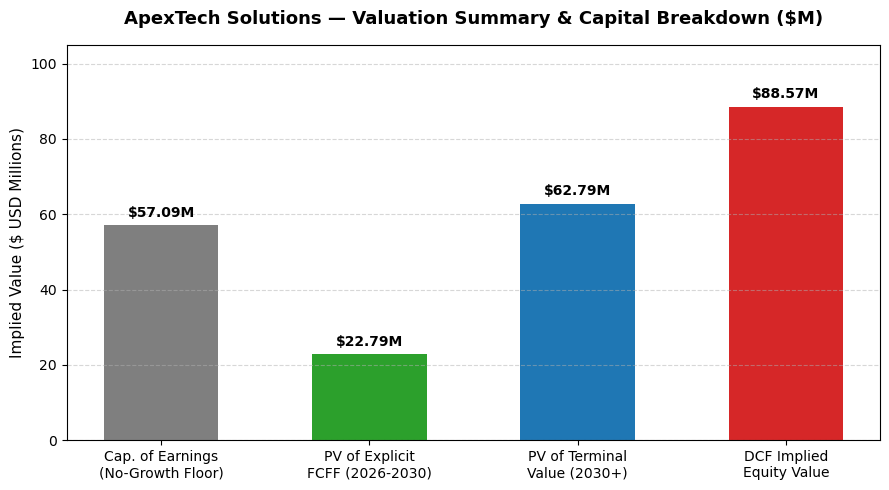

In [7]:
# Data for valuation conclusion chart
categories = [
    'Cap. of Earnings\n(No-Growth Floor)',
    'PV of Explicit\nFCFF (2026-2030)',
    'PV of Terminal\nValue (2030+)',
    'DCF Implied\nEquity Value',
]
values = [57.09, 22.79, 62.79, 88.57]
colors = ['#7f7f7f', '#2ca02c', '#1f77b4', '#d62728']

# Initialize plot
plt.figure(figsize=(9, 5))
bars = plt.bar(categories, values, color=colors, width=0.55)

# Plot formatting
plt.title(
    'ApexTech Solutions — Valuation Summary & Capital Breakdown ($M)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.ylabel('Implied Value ($ USD Millions)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add data labels on top of bars
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 1.5,
      f'${yval:.2f}M',
      ha='center',
      va='bottom',
      fontweight='bold',
      fontsize=10,
  )

plt.ylim(0, 105)
plt.tight_layout()

# Save high-res image file and display inline in Jupyter
plt.savefig('valuation_conclusion_summary.png', dpi=300)
plt.show()

### Summary of Interpretations

**The main Target Metrics**

* DCF Intrinsic Value: $8.86 / share ($88.57M Enterprise Value based on 10M diluted shares).
* Capitalization of Earnings Value: $5.71 / share ($57.09M Equity Value).
* Discount / Growth Profile: 10.175% WACC with a conservative Terminal Growth Rate.
* Balance Sheet Position: Net Cash position of +$3.00M (no net debt position).

**Main Valuation Considerations**

* Value Breakdown (DCF Model): The explicit 5-year forecast period (2026E–2030E) has present value of $22.79M, whereas the Terminal Value (discounted) is $62.78M ($101.92M nominal). The high Terminal Weighting is consistent with a standard growth profile where enterprise value is weighted to future mature business operations.
* Valuation Spread Analysis: The DCF valuation trades at a +55.2% premium over the Capitalization of Earnings valuation baseline (+$3.15 per share spread). The spread represents the monetary value created through the expected 5-year plan of revenue growth and margin improvement.
* Floor Valuation: The $5.71/share** Capitalization of Earnings value represents a conservative floor valuation which assumes no growth beyond historical 2025 earnings.

**Strategic Implications**

The company has sound capital strength and no debt risks. The $5.71 floor creates substantial downside protection, while $8.86 DCF target captures upside through execution of growth strategy over next 5 years.

### Conclusion & Recommendation

Based on the quantitative analysis, normalized financial modeling, and intrinsic cash flow projections for ApexTech Solutions Ltd., the baseline valuation conclusions are summarized below.

#### A. Final Valuation Synthesis

•	***Primary Recommendation (Discounted Cash Flow Method):***
o	Implied Enterprise Value (EV): $85.57M
o	Net Cash Adjustment: +$3.00M ($5.50M Cash less $2.50M Debt)
o	Implied Equity Value: $88.57M
o	Intrinsic Value Per Share: $8.86 / share (based on 10.0M diluted shares outstanding)

•	***Baseline Risk Floor (Capitalization of Earnings Method):***

o	Implied Equity Value: $57.09M

o	Intrinsic Value Per Share: $5.71 / share


#### B. Core Strategic Insights

•	***Growth Premium Quantification:*** The $3.15 per share (+55.2%) premium of the DCF model ($8.86) over the Capitalization of Earnings baseline ($5.71) reflects the present value of the firm's anticipated revenue expansion (12% CAGR) and margin improvements through 2030E.

•	***Terminal Value Dominance:*** The terminal value accounts for 73.4% ($62.79M) of the total Enterprise Value, which is typical for expanding Enterprise SaaS businesses. Long-term valuation stability depends heavily on achieving steady-state growth ($g = 2.50\%$) beyond 2030E.


•	***Strong Balance Sheet Position:*** Possessing $3.00M in net cash provides downside protection and financial flexibility to execute capital expenditures and operational plans without immediate dilution or refinancing risks.

#### C. Concluding Recommendation
For M&A negotiations, equity investment, or strategic advisory:

•	****Target Offer Range: $8.50 – $9.20 per share**** (centered around the $8.86 / share DCF intrinsic baseline).

•	****Floor Price: $5.71 per share****, below which the company would be priced under a zero-growth scenario.